# Chapter 1: Introduction to Image Processing

## Part 1: Understanding Digital Image Processing


### What is Digital Image Processing?
Digital image processing involves using algorithms and mathematical models to process and analyze digital images. The goal is to enhance image quality, extract meaningful information, and automate image-based tasks.

> **💡 Note on Modern Computer Vision:** 
> While classical image processing focuses on fundamental pixel manipulations, it serves as the crucial foundation for modern Computer Vision. Mastering these core concepts is essential before advancing to Deep Learning-based frameworks (such as YOLO for real-time object detection), where these traditional techniques are heavily utilized for image preprocessing and data augmentation.

### The Objective of Image Processing
The primary objectives of image processing are:
1. **Visualization**: Observe objects that are not visible.
2. **Image sharpening and restoration**: Improve the quality of an image.
3. **Image retrieval**: Seek for the image of interest.
4. **Measurement of pattern**: Measures various objects in an image.
5. **Image recognition**: Distinguish the objects in an image.




### The basic steps in digital image processing are:

**Overall Workflow:**
`Acquisition` ➔ `Enhancement` ➔ `Restoration` ➔ `Morphological Processing` ➔ `Segmentation` ➔ `Representation` ➔ `Recognition`

Here is a detailed look at the fundamental steps:

### 1. Image Acquisition
Capturing an image digitally or importing an existing image.
* **The Process:** Converts physical energy (such as illumination or X-rays) reflected or emitted by an object into a digital format. 
* **Key Components:** This requires an imaging sensor and the processes of **sampling** (digitizing spatial coordinates) and **quantization** (digitizing amplitude values) to form a pixel matrix.

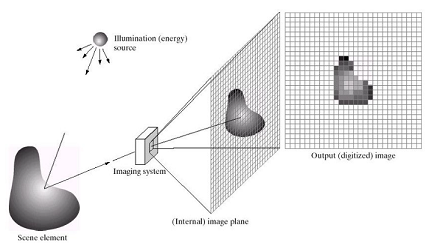

### 2. Image Enhancement
Improving visual quality to make the image more suitable for a specific task.
* **The Process:** A highly subjective step where the image is manipulated (e.g., adjusting contrast, brightness, or sharpening edges) so the result is more suitable than the original for a specific application or human viewing.
* **Common Techniques:** Histogram equalization, noise smoothing, and spatial filtering.

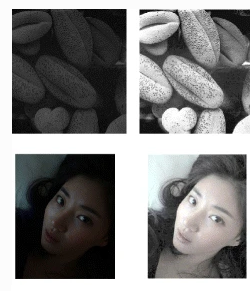

### 3. Image Restoration
Removing or reducing degradations such as blur, noise, or optical distortion.
* **The Process:** Unlike enhancement, restoration is **objective**. It involves using mathematical models of image degradation (e.g., motion blur, sensor noise) to attempt to reverse the damage and recover the original, uncorrupted image.
* **Common Techniques:** Applying specific filters to remove anomalies like Salt and Pepper noise (as shown below).

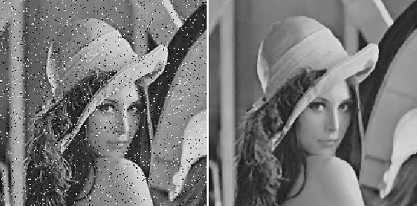

### 4. Image Segmentation
Partitioning an image into multiple distinct regions or objects.
* **The Process:** Separating the foreground (objects of interest) from the background. This is a foundational step that transitions classical image processing into deeper analysis, laying the groundwork for identifying specific classes and objects.
* **Common Techniques:** Thresholding, edge detection, and region growing.

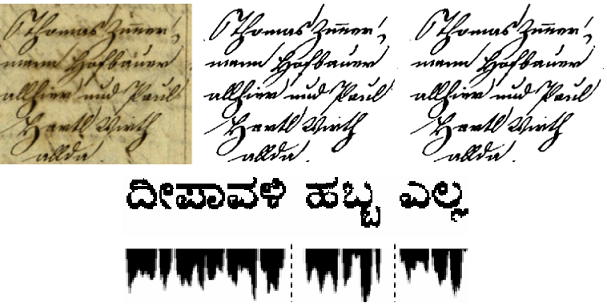

5. **Image representation & description:** Representing the image for computer analysis.

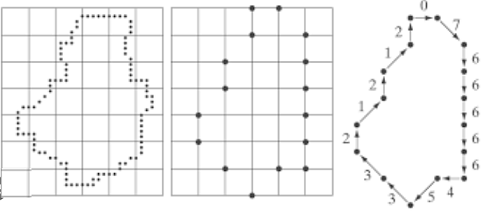

### 1. Color Images (RGB)
Images representing color, typically using three separate channels: Red, Green, and Blue.
* **Data Structure:** Represented as a 3D matrix with dimensions $H \times W \times C$ (Height, Width, Channels). 
* **Depth:** A standard 24-bit RGB image allocates 8 bits per channel, allowing for values from $0$ to $255$ in each color matrix.
* **Note:** Other color spaces like HSV/HSL are also widely used depending on the processing task.

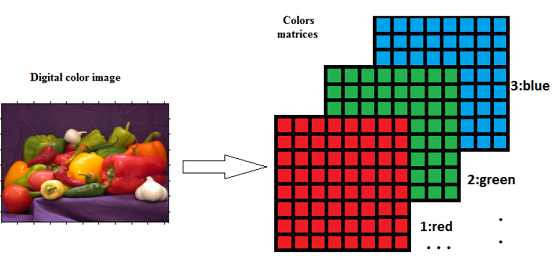

### 2. Grayscale Images
Monochrome images containing only intensity (brightness) information, with no color.
* **Data Structure:** Represented as a 2D matrix with dimensions $H \times W$.
* **Depth:** Typically 8 bits per pixel (`uint8`), allowing 256 different gray levels ranging from $0$ (black) to $255$ (white).
* **Usage:** Widely used because they contain sufficient structural information for many computer vision tasks (like edge detection) while being computationally much faster and requiring less memory than color images.

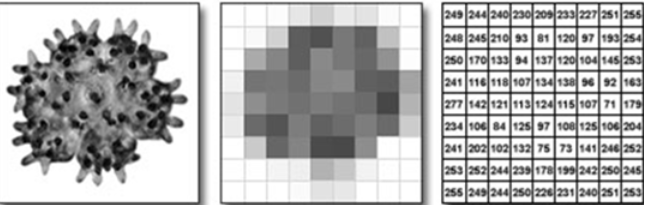

### 3. Binary Images
The simplest form of an image, containing only two possible pixel values.
* **Data Structure:** Represented as a 2D matrix with dimensions $H \times W$.
* **Depth:** Conceptually 1-bit per pixel (representing $0$ for black, and $1$ for white). In coding practice, often scaled to $0$ and $255$.

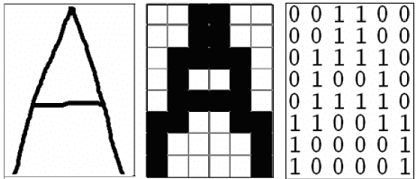

<b>Multispectral images:</b> Images with data outside the normal visible range, such as infrared, ultraviolet, X-ray etc. The spectral bands are mapped to visual colors for display.

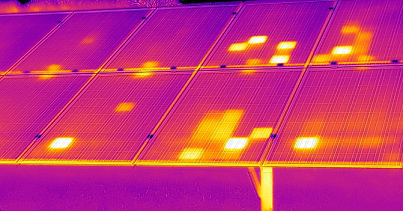

## Basic Image Processing Operations with OpenCV

Digital images are typically obtained by:
1. Capturing physical scenes via sensors (e.g., digital cameras, scanners).
2. Importing existing digital image files from local storage or URLs.

OpenCV (Open Source Computer Vision Library) is a powerful tool that can read, process, and write a wide variety of image formats, including JPG, PNG, and TIFF.

## Digital Image Coordinate System

A digital image can be mathematically defined as a 2D function $f(i,j)$, where $i$ and $j$ are spatial coordinates. The amplitude of $f$ at any pair of coordinates $(i,j)$ is called the **intensity** or **gray level** of the image at that point.

**⚠️ Crucial Concept: The Origin (0,0)**
Unlike standard Cartesian coordinates where the origin is at the bottom-left, the image coordinate system places the **origin (0,0) at the top-left corner**. 

When working with Python and OpenCV, images are represented as NumPy arrays. It is highly important to understand how these spatial coordinates map directly to matrix indices:
* **$i$-axis (Rows / Vertical):** Represents the height of the image (moving from top to bottom).
* **$j$-axis (Columns / Horizontal):** Represents the width of the image (moving from left to right).
* **Array Indexing:** Accessed via row first, then column as `image[i, j]`.

For an image with dimensions $M \times N$ ($M$ rows/height and $N$ columns/width), the matrix representation is:

| | Col 0 ($j=0$) | Col 1 ($j=1$) | ... | Col $N-1$ ($j=N-1$) |
|---|---|---|---|---|
| **Row 0 ($i=0$)** | $f(0,0)$ | $f(0,1)$ | ... | $f(0,N-1)$ |
| **Row 1 ($i=1$)** | $f(1,0)$ | $f(1,1)$ | ... | $f(1,N-1)$ |
| **...** | ... | ... | ... | ... |
| **Row $M-1$ ($i=M-1$)** | $f(M-1,0)$ | $f(M-1,1)$ | ... | $f(M-1,N-1)$ |

Here the image has dimensions $M \times N$ pixels.

## Basic OpenCV Operations
Before diving into advanced algorithms, we must understand the fundamental I/O (Input/Output) operations using Python and OpenCV. Here is the standard workflow we will execute in the following cells:

1. **Reading an Image (`cv2.imread`)**: Loading an image from the disk into a NumPy array structure.
2. **Resizing an Image (`cv2.resize`)**: Changing the spatial dimensions (M x N) of the image matrix.
3. **Converting Color Spaces (`cv2.cvtColor`)**: Transforming an image from one color space to another (e.g., converting a standard OpenCV BGR image to Grayscale).
4. **Displaying an Image (`cv2.imshow` or `plt.imshow`)**: Rendering the numerical matrix back into a visual format on the screen.

> **Note:** Mastering these basic operations is the first step toward building advanced computer vision applications, from simple automated inspection scripts to complex object detection models like YOLO.

In [1]:
import cv2
import matplotlib.pyplot as plt

(512, 512, 3) <class 'numpy.ndarray'>


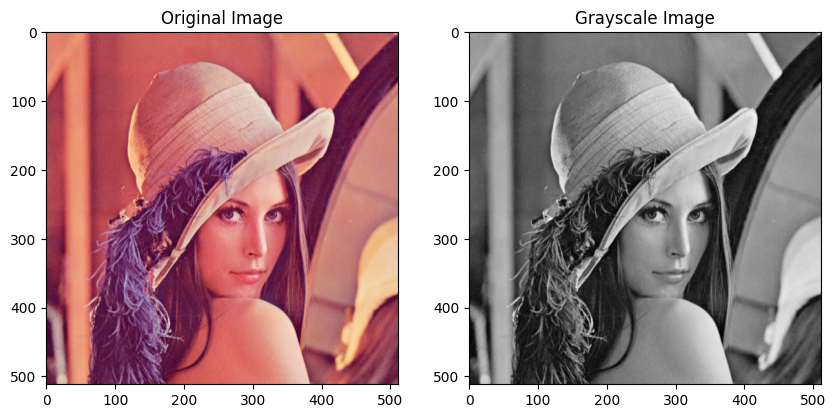

In [2]:
# Opening and Reading an Image
image_path = 'lena.png'
image = cv2.imread(image_path)

print(image.shape, type(image))
# Resizing
resized_image = cv2.resize(image, (500, 400))  # Resize to 500x400 pixels

# Converting to Grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Displaying Images
plt.figure(figsize=(10, 5))

plt.subplot(121)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))  # Convert BGR to RGB for display
plt.title('Original Image')

plt.subplot(122)
plt.imshow(gray_image, cmap='gray')
plt.title('Grayscale Image')

plt.show()


### Notes
Here's a comparison of basic image processing operations using OpenCV, scikit-image, and PIL (Pillow), along with code examples and image format conversions:
#### 1.Read Image


In [22]:
import cv2
from skimage import io
from skimage.transform import rescale, resize
from skimage.color import rgb2gray
from PIL import Image

In [15]:
img_name = 'cells.tif'
# OpenCV
img_cv = cv2.imread(img_name)  # Reads in BGR format

# scikit-image
img_ski = io.imread(img_name)

# PIL
img_pil = Image.open(img_name)  


#### 2. Write Image

In [16]:
# OpenCV
cv2.imwrite('output_cv.jpg', img_cv)

# scikit-image
io.imsave('output_ski.jpg', img_ski)

# PIL
img_pil.save('output_pil.jpg')


#### 3. Resize Image

In [19]:
import numpy as np

# OpenCV
resized_cv = cv2.resize(img_cv, (500, 300))

# scikit-image
resized_ski = resize(img_ski, (300, 500))

# PIL
resized_pil = img_pil.resize((500, 300))


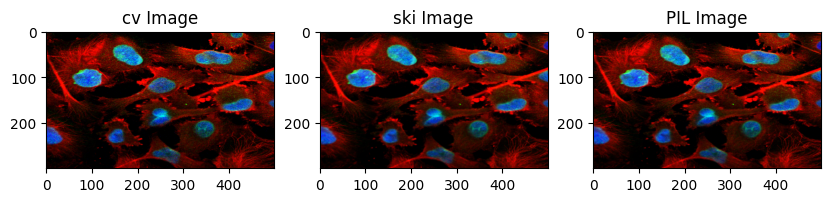

In [21]:
plt.figure(figsize=(10, 5))

plt.subplot(131)
plt.imshow(cv2.cvtColor(resized_cv, cv2.COLOR_BGR2RGB))  
plt.title('cv Image')

plt.subplot(132)
plt.imshow(resized_ski)
plt.title('ski Image')

plt.subplot(133)
plt.imshow(resized_pil)
plt.title('PIL Image')

plt.show()

#### 4. Convert to Grayscale

In [23]:
# OpenCV
gray_cv = cv2.cvtColor(img_cv, cv2.COLOR_BGR2GRAY)

# scikit-image

gray_ski = rgb2gray(img_ski)

# PIL
gray_pil = img_pil.convert('L') 


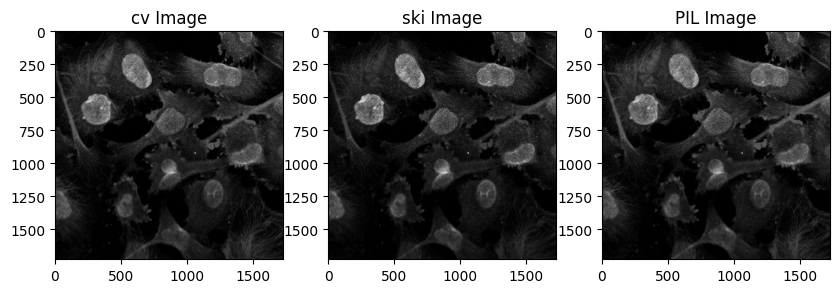

In [24]:
plt.figure(figsize=(10, 5))

plt.subplot(131)
plt.imshow(gray_cv, cmap='gray')  
plt.title('cv Image')

plt.subplot(132)
plt.imshow(gray_ski, cmap='gray')  
plt.title('ski Image')

plt.subplot(133)
plt.imshow(gray_pil, cmap='gray')  
plt.title('PIL Image')

plt.show()

#### 5. Image Format Conversions

In [ ]:
# OpenCV to PIL
img_pil = Image.fromarray(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB))

# PIL to OpenCV
img_cv = cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)

# OpenCV to scikit-image (no conversion needed, usually)
img_ski = img_cv

# scikit-image to OpenCV (no conversion needed, usually)
img_cv = img_ski

# PIL to scikit-image
img_ski = np.array(img_pil)

# scikit-image to PIL
img_pil = Image.fromarray(img_ski)
